# Digital Marketing Analytics: CTR, CPC & Conversion Rate

**Dataset:** `conversion.csv` — Facebook ad campaign performance data

**Topics:**
1. Exploratory Data Analysis (EDA)
2. Impressions distribution (log-transform, bimodality)
3. Click-Through Rate (CTR)
4. Cost Per Click (CPC) — IQR, boxplot
5. CPC by gender
6. Conversion Rate (CR)


## Dataset Description

| Column | Type | Description |
|--------|------|-------------|
| `ad_id` | int | Unique ad identifier |
| `xyz_campaign_id` | int | Campaign ID in company X's system |
| `fb_campaign_id` | int | Campaign ID on Facebook |
| `age` | str | Age group shown the ad |
| `gender` | str | Gender of target audience |
| `interest` | int | Interest category code |
| `Impressions` | int | Number of times the ad was shown |
| `Clicks` | int | Number of clicks on the ad |
| `Spent` | float | Amount spent showing the ad (USD) |
| `Total_Conversion` | int | Users who expressed interest after seeing the ad |
| `Approved_Conversion` | int | Users who purchased after seeing the ad |


In [13]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Exploratory Data Analysis

Check shape, dtypes, missing values, and unique values per column.


In [14]:
data = pd.read_csv('data/conversion.csv')
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ad_id                1143 non-null   int64  
 1   xyz_campaign_id      1143 non-null   int64  
 2   fb_campaign_id       1143 non-null   int64  
 3   age                  1143 non-null   str    
 4   gender               1143 non-null   str    
 5   interest             1143 non-null   int64  
 6   Impressions          1143 non-null   int64  
 7   Clicks               1143 non-null   int64  
 8   Spent                1143 non-null   float64
 9   Total_Conversion     1143 non-null   int64  
 10  Approved_Conversion  1143 non-null   int64  
dtypes: float64(1), int64(8), str(2)
memory usage: 98.4 KB


In [15]:
print('Unique values per column:')
data.apply(lambda x: x.nunique())

Unique values per column:


ad_id                  1143
xyz_campaign_id           3
fb_campaign_id          691
age                       4
gender                    2
interest                 40
Impressions            1130
Clicks                  183
Spent                   869
Total_Conversion         32
Approved_Conversion      16
dtype: int64

In [16]:
data.head()

,ad_id,xyz_campaign_id,fb_campaign_id,age,gender,interest,Impressions,Clicks,Spent,Total_Conversion,Approved_Conversion
0,708746,916,103916,30-34,M,15,7350,1,1.43,2,1
1,708749,916,103917,30-34,M,16,17861,2,1.82,2,0
2,708771,916,103920,30-34,M,20,693,0,0.00,1,0
3,708815,916,103928,30-34,M,28,4259,1,1.25,1,0
4,708818,916,103928,30-34,M,28,4133,1,1.29,1,1


## 2. Impressions Distribution (Log-Transformed)

Raw impression counts are often **right-skewed** (a few ads get many more views).  
Taking the **natural log** compresses the scale and reveals the shape:

$$x' = \ln(\text{Impressions})$$

A **bimodal** distribution here suggests two distinct audience groups or campaign types.


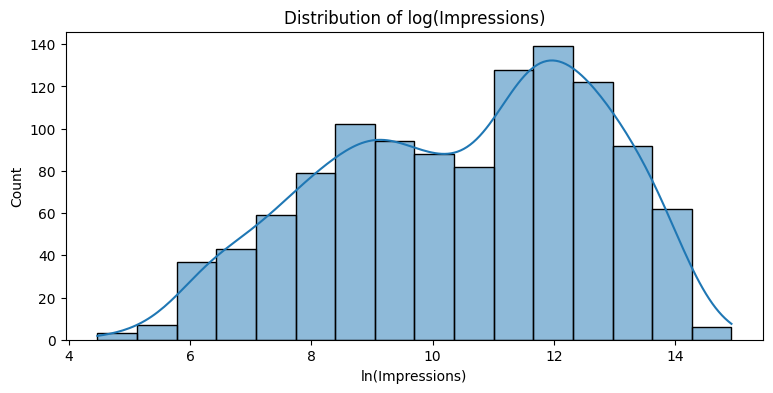

In [17]:
plt.figure(figsize=(9, 4))
sns.histplot(np.log(data.Impressions), kde=True)
plt.title('Distribution of log(Impressions)')
plt.xlabel('ln(Impressions)')
plt.show()
# Bimodal — two distinct impression-count clusters across campaigns

## 3. Click-Through Rate (CTR)

**CTR** measures how often people who see an ad actually click on it:

$$CTR = \frac{\text{Clicks}}{\text{Impressions}}$$

- Higher CTR → ad is more relevant / engaging to the audience
- Typical display CTR: 0.1%–0.3%; search ads can reach 5%+


In [18]:
data['CTR'] = data.Clicks / data.Impressions

print('CTR descriptive stats:')
print(data['CTR'].describe())

print('\nAd with highest CTR:')
data.sort_values('CTR', ascending=False).head(1)[['ad_id', 'Clicks', 'Impressions', 'CTR']]

CTR descriptive stats:
count    1143.000000
mean        0.000164
std         0.000115
min         0.000000
25%         0.000100
50%         0.000160
75%         0.000234
max         0.001059
Name: CTR, dtype: float64

Ad with highest CTR:


,ad_id,Clicks,Impressions,CTR
150,738637,1,944,0.001059


Unique campaign IDs: [ 916  936 1178]


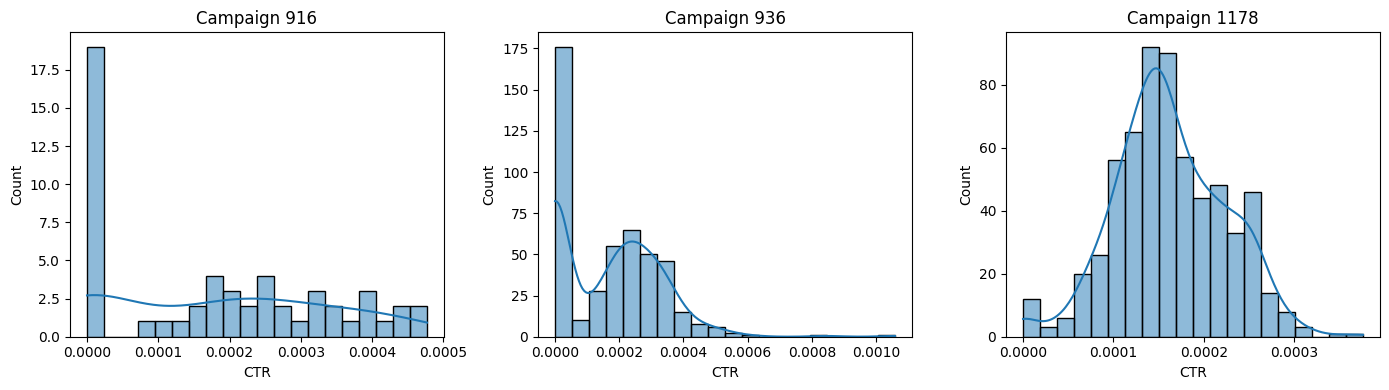

In [19]:
# CTR distribution by campaign
print('Unique campaign IDs:', data.xyz_campaign_id.unique())

fig, axes = plt.subplots(1, data.xyz_campaign_id.nunique(), figsize=(14, 4), sharey=False)
for ax, cid in zip(axes, sorted(data.xyz_campaign_id.unique())):
    subset = data.query('xyz_campaign_id == @cid')
    sns.histplot(x='CTR', data=subset, bins=20, kde=True, ax=ax)
    ax.set_title(f'Campaign {cid}')
plt.tight_layout()
plt.show()

## 4. Cost Per Click (CPC)

**CPC** is the average cost paid for each click:

$$CPC = \frac{\text{Spent}}{\text{Clicks}}$$

**Key measures of spread:**

| Measure | Formula | Notes |
|---------|---------|-------|
| Range | $x_{\max} - x_{\min}$ | Sensitive to outliers |
| IQR | $Q_3 - Q_1$ | Robust to outliers |
| Std Dev | $s = \sqrt{\frac{\sum(x_i-\bar{x})^2}{n-1}}$ | Same units as data |

Ads with `Clicks = 0` will produce `NaN` for CPC — handled with `dropna()`.


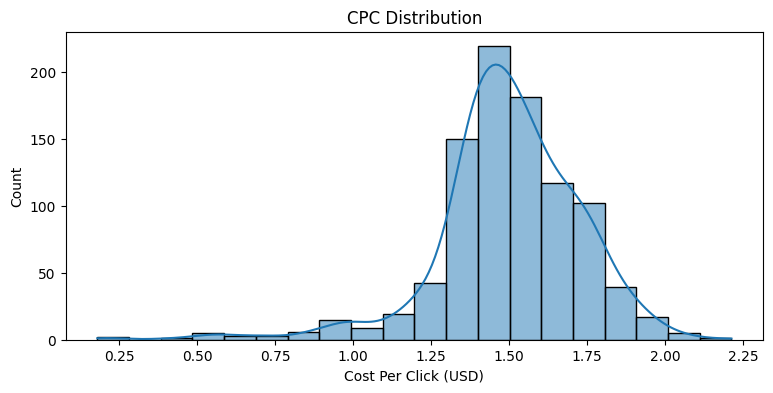

In [20]:
data['CPC'] = data.Spent / data.Clicks

plt.figure(figsize=(9, 4))
sns.histplot(data.CPC.dropna(), bins=20, kde=True)
plt.title('CPC Distribution')
plt.xlabel('Cost Per Click (USD)')
plt.show()

In [21]:
print('CPC descriptive stats:')
data['CPC'].describe()

CPC descriptive stats:


count    936.000000
mean       1.499347
std        0.232879
min        0.180000
25%        1.390000
50%        1.498273
75%        1.644364
max        2.212000
Name: CPC, dtype: float64

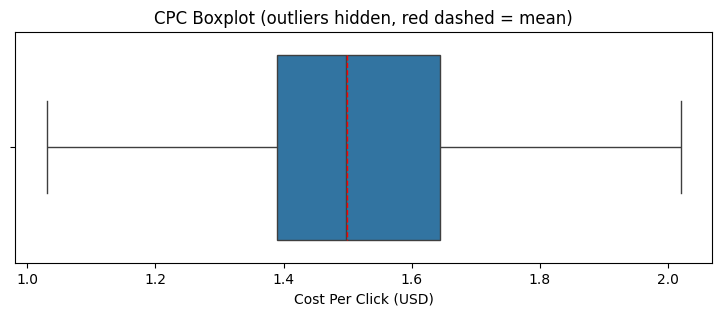

In [22]:
fig, ax = plt.subplots(figsize=(9, 3))
sns.boxplot(data.CPC.dropna(), orient='h', showfliers=False,
            showmeans=True, meanline=True,
            meanprops={'color': 'red', 'ls': '--'}, ax=ax)
ax.set_title('CPC Boxplot (outliers hidden, red dashed = mean)')
ax.set_xlabel('Cost Per Click (USD)')
plt.show()

In [24]:
iqr = stats.iqr(data.CPC.dropna())
print(f'IQR (Q3 - Q1): {iqr:.2f}')

IQR (Q3 - Q1): 0.25


## 5. CPC by Gender

Compare CPC distributions across gender groups using overlaid density plots.  
`stat='density'` + `common_norm=False` normalizes each group independently,  
so shapes are comparable regardless of group size.


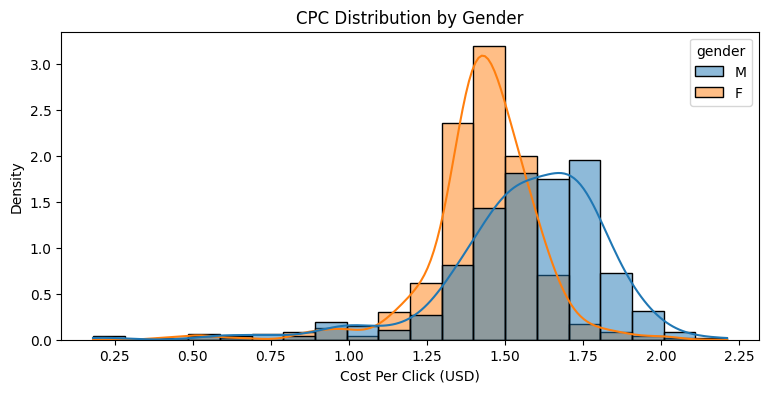

In [25]:
plt.figure(figsize=(9, 4))
sns.histplot(x='CPC', data=data, hue='gender',
             bins=20, kde=True, stat='density', common_norm=False)
plt.title('CPC Distribution by Gender')
plt.xlabel('Cost Per Click (USD)')
plt.show()

## 6. Conversion Rate (CR)

**Conversion Rate** measures the share of users who completed a target action  
at a given funnel stage:

$$CR_{\text{click→purchase}} = \frac{\text{Approved\_Conversion}}{\text{Clicks}}$$

**Marketing funnel stages (example):**

```
Impressions → Clicks → Total_Conversion → Approved_Conversion
      (CTR)              (interest CR)           (purchase CR)
```

Each stage CR = (next stage) / (current stage).


In [26]:
data['CR'] = data.Approved_Conversion / data.Clicks
data['CR'] = data['CR'].replace([np.inf, -np.inf], np.nan)

print('CR descriptive stats:')
print(data['CR'].describe())

ad_cr = data.query('ad_id == 1121814')[['ad_id', 'Clicks', 'Approved_Conversion', 'CR']]
print(f'\nAd 1121814 CR: {ad_cr.CR.values[0]*100:.2f}%')
ad_cr

CR descriptive stats:
count    936.000000
mean       0.109030
std        0.247032
min        0.000000
25%        0.000000
50%        0.012539
75%        0.066667
max        2.000000
Name: CR, dtype: float64

Ad 1121814 CR: 3.09%


,ad_id,Clicks,Approved_Conversion,CR
860,1121814,421,13,0.030879
